In [10]:
import sys
sys.path.append("..")

In [11]:
import numpy as np
from feature_analysis.feature_extract import FeatureExtractManager

In [12]:
kernels_dataset = np.load("../Kernels_datasets_numpy/kernel_dataset_3.npy", allow_pickle=True).item()
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


In [13]:
feature_list = ['variance', 'glcm_correlation',     # Obtenida de análisis preliminares
                'energy_1st', 'glcm_entropy', 
                'skewness','kurtosis']


--- RANKING DE CARACTERÍSTICAS ---
        Caracteristica  Score_Final  Info_Mutua  RF_Importancia
0             variance     0.985104    0.315895        0.123763
1     glcm_correlation     0.960772    0.291111        0.127563
2         glcm_entropy     0.585597    0.181690        0.076032
3           energy_1st     0.580860    0.146350        0.089094
4             kurtosis     0.550937    0.165076        0.073898
5              mean_hu     0.534549    0.128845        0.084348
6             skewness     0.487839    0.091678        0.087439
7          glcm_energy     0.481294    0.156748        0.059493
8    ldop_grad_90_mean     0.328327    0.072680        0.054415
9    ldop_grad_45_mean     0.293255    0.071719        0.045856
10  ldop_grad_135_mean     0.276091    0.068613        0.042731
11       glcm_contrast     0.261252    0.049197        0.046786
12    glcm_homogeneity     0.261006    0.041318        0.049905
13    ldop_grad_0_mean     0.227197    0.047759        0.038678


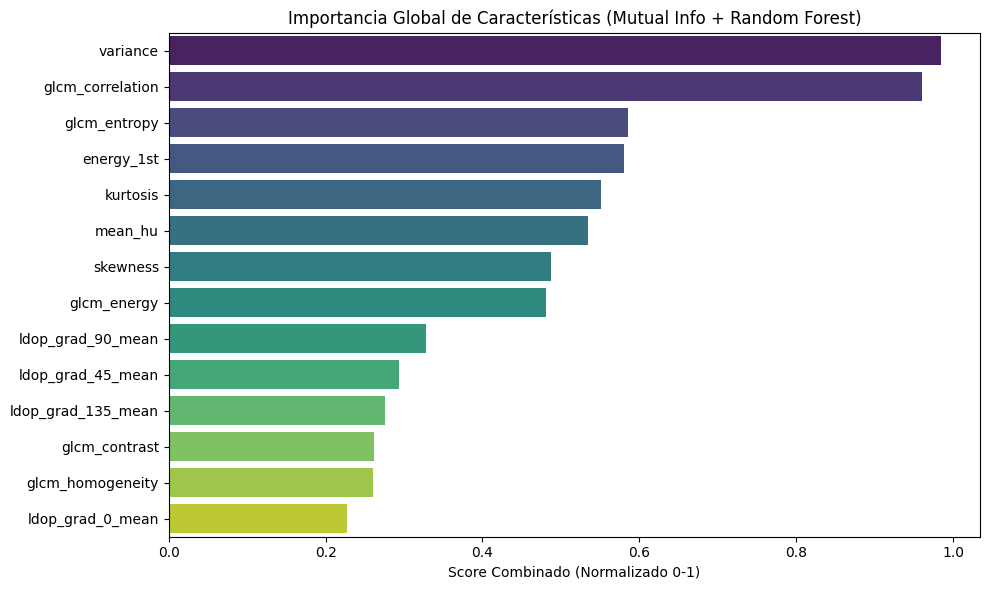

Calculando matriz de correlación cruzada...


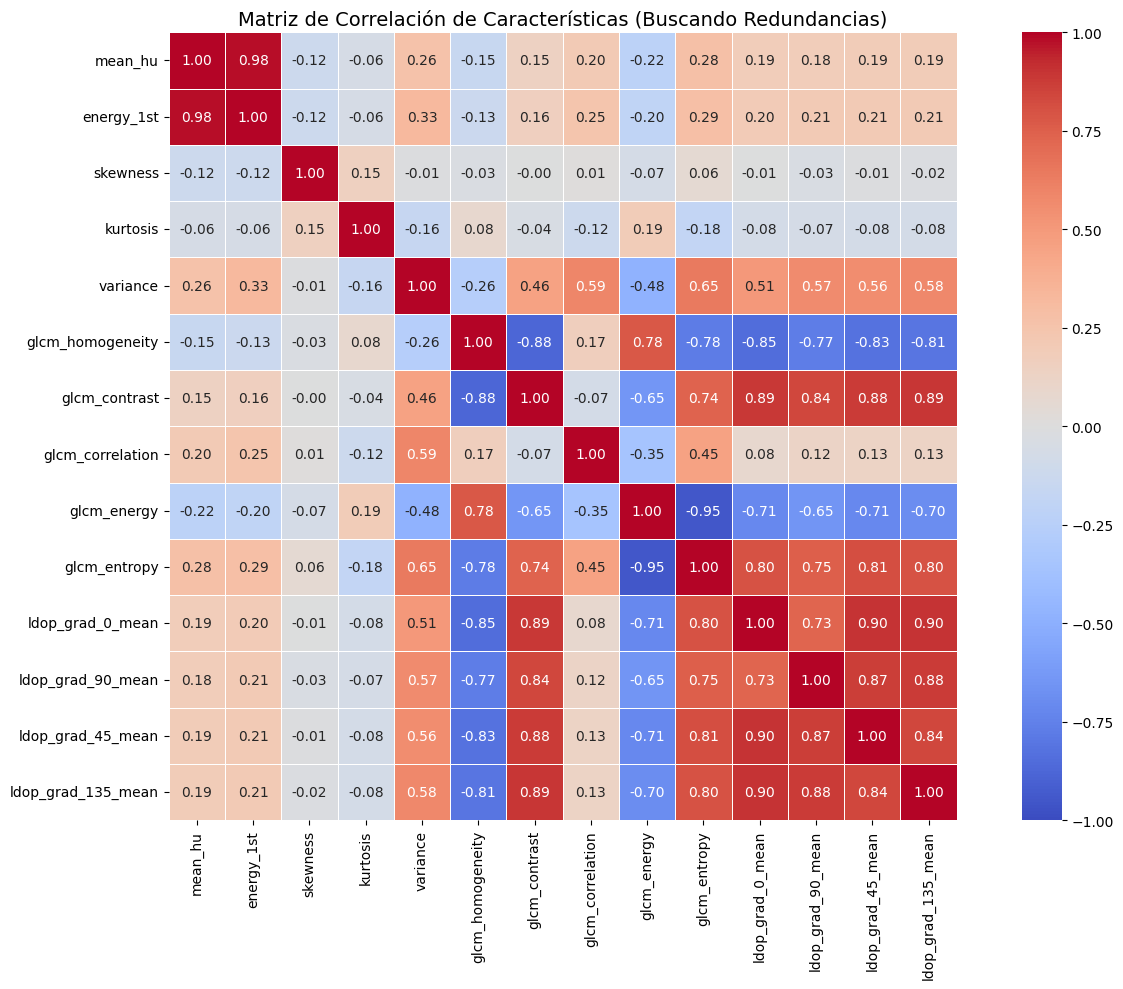

In [14]:
from feature_evaluation.feature_evaluator import FeatureEvaluator
evaluator = FeatureEvaluator(df_features, analysis=True)

In [15]:
ranking = evaluator.rank_feature_combinations(feature_list, max_size=6)

Analizando combinaciones de '['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']'...

--- TOP 5 MEJORES COMBINACIONES ---
    num_features                                           features  accuracy
58             5  variance, glcm_correlation, energy_1st, skewne...  0.775852
62             6  variance, glcm_correlation, energy_1st, glcm_e...  0.773541
61             5  glcm_correlation, energy_1st, glcm_entropy, sk...  0.767187
56             5  variance, glcm_correlation, energy_1st, glcm_e...  0.760832
60             5  variance, energy_1st, glcm_entropy, skewness, ...  0.760254
49             4           variance, energy_1st, skewness, kurtosis  0.755055
51             4  glcm_correlation, energy_1st, glcm_entropy, sk...  0.752744
42             4   variance, glcm_correlation, energy_1st, skewness  0.751011
47             4       variance, energy_1st, glcm_entropy, skewness  0.744656
57             5  variance, glcm_correlation, energy_1st, glcm_

In [16]:
best_features_kernel_1 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_1)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 76.60%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.49%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 47.54%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 47.89%
..............................

GANADOR DEL BENCHMARK: Random Forest con 76.60% de precisión.


In [17]:
best_features_kernel_2 = ['variance', 'glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_2)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.41%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.72%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 47.72%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 53.15%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.41% de precisión.


In [18]:
best_features_kernel_3 = ['variance', 'glcm_correlation', 'energy_1st', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_3)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 77.24%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.66%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 47.54%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 53.15%
..............................

GANADOR DEL BENCHMARK: Random Forest con 77.24% de precisión.


In [19]:
best_features_kernel_4 = ['glcm_correlation', 'energy_1st', 'glcm_entropy', 'skewness', 'kurtosis']
models = evaluator.run_models_benchmark(best_features_kernel_4)

--------------------------------------------------
INICIANDO BENCHMARK DE MODELOS
--------------------------------------------------
Datos de Entrenamiento: 6921 parches
Datos de Prueba (Test): 1731 parches

--- Random Forest ---
Precisión Global (Accuracy): 76.60%
..............................
--- Gradient Boosting (XGBoost lite) ---
Precisión Global (Accuracy): 76.49%
..............................
--- Support Vector Machine (SVM) ---
Precisión Global (Accuracy): 47.54%
..............................
--- Naïve Bayes ---
Precisión Global (Accuracy): 47.89%
..............................

GANADOR DEL BENCHMARK: Random Forest con 76.60% de precisión.
